In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Treain MAE')
plt.plot(history.history['val_mae'], label='validation MAE')
plt.title("MAE Curve")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

## 텐서플로우 이진 분류(Binary Classification)

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences # 리뷰 텍스트 내용의 길이가 다르기 때문에 동일한 길이로 맞추기 위해 패딩 기능을 적용
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

In [2]:
# 영화 리뷰를 긍정/부정 두 가지로 분류하는 모델
# 1. IMDB 데이터 로드
(x_train, y_train), (x_test,y_test) = imdb.load_data(num_words=10000)
# 가장 많이 등장햿던 단어 10000개만 사용해서 단어를 정수 인덱스로 변환

In [7]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [3]:
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [4]:
model = models.Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=max_len),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

C:\Users\human\anaconda3\envs\ai\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.7710 - loss: 0.4658 - val_accuracy: 0.8506 - val_loss: 0.3501
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8969 - loss: 0.2617 - val_accuracy: 0.8716 - val_loss: 0.3076
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9281 - loss: 0.1948 - val_accuracy: 0.8666 - val_loss: 0.3239
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.9448 - loss: 0.1543 - val_accuracy: 0.8646 - val_loss: 0.3633
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9592 - loss: 0.1203 - val_accuracy: 0.8624 - val_loss: 0.3632


In [7]:
acc = model.evaluate(x_test, y_test)[1]
print("Test Accuracy : ", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8562 - loss: 0.3887
Test Accuracy :  0.8561999797821045


In [8]:
pred = model.predict(x_test[:5])

print("예측 확률: ", pred)
print("예측 결과: ", (pred > 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
예측 확률:  [[0.24650948]
 [0.99625295]
 [0.6947841 ]
 [0.1311902 ]
 [0.99931645]]
예측 결과:  [[0]
 [1]
 [1]
 [0]
 [1]]


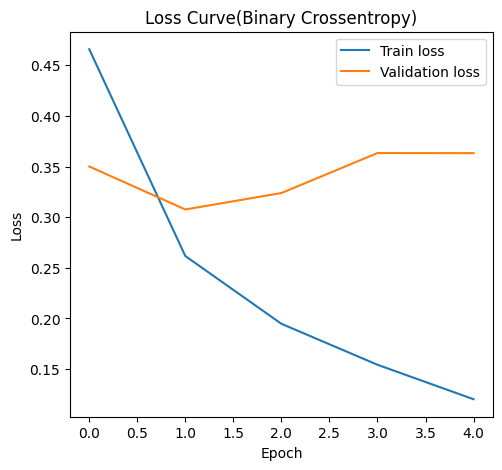

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("Loss Curve(Binary Crossentropy)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

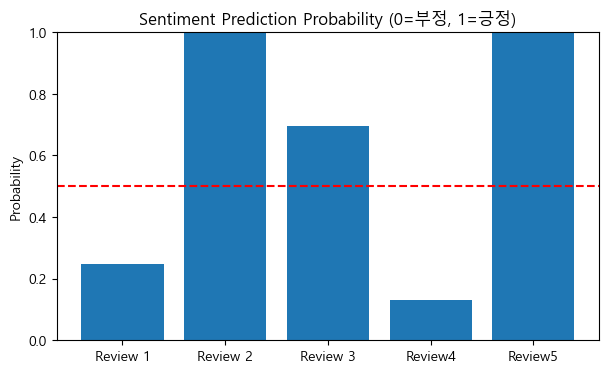

In [12]:
pred_probs = pred.reshape(-1)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7,4))
plt.bar([1,2,3,4,5], pred_probs)
plt.axhline(0.5, color='red', linestyle='--')
plt.xticks([1,2,3,4,5], ['Review 1', 'Review 2', 'Review 3', 'Review4', 'Review5'])
plt.ylim(0,1)
plt.title("Sentiment Prediction Probability (0=부정, 1=긍정)")
plt.ylabel("Probability")
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_5312\511433118.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


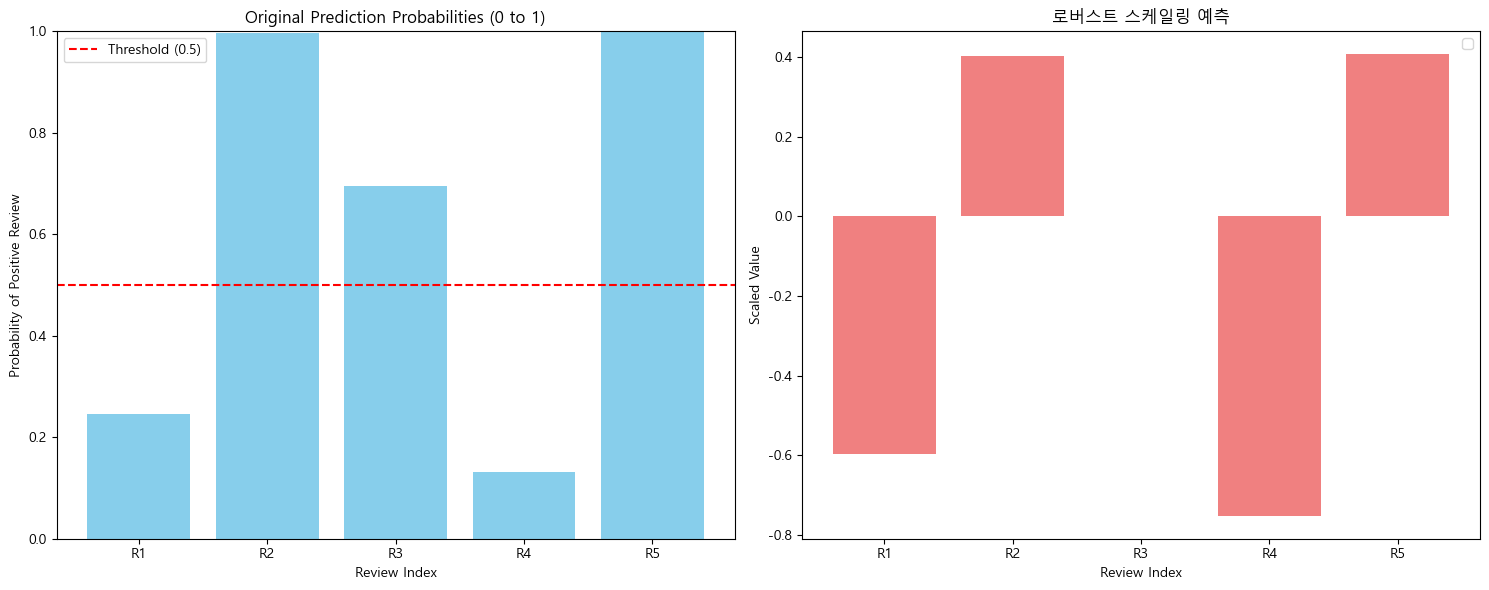

In [17]:
sample_reviews = x_test[:5]
pred_probs = model.predict(sample_reviews, verbose=0).flatten() 

scaler = RobustScaler() 

pred_probs_reshaped = pred_probs.reshape(-1, 1)

scaled_pred_probs = scaler.fit_transform(pred_probs_reshaped).flatten()


plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.bar(range(1, 6), pred_probs, color='skyblue') 
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title("Original Prediction Probabilities (0 to 1)")
plt.xlabel("Review Index")
plt.ylabel("Probability of Positive Review")
plt.xticks(range(1, 6), ['R1', 'R2', 'R3', 'R4', 'R5'])
plt.legend()
plt.ylim(0, 1) 

plt.subplot(1, 2, 2)
plt.bar(range(1, 6), scaled_pred_probs, color='lightcoral') 
plt.title("로버스트 스케일링 예측")
plt.xlabel("Review Index")
plt.ylabel("Scaled Value")
plt.xticks(range(1, 6), ['R1', 'R2', 'R3', 'R4', 'R5'])
plt.legend()

plt.tight_layout()
plt.show()

### 3. 텐서플로우 다중 분류(Multi-Class Classification)

In [1]:
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences # 리뷰 텍스트 내용의 길이가 다르기 때문에 동일한 길이로 맞추기 위해 패딩 기능을 적용
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

In [3]:
(x_train, y_train), (x_test,y_test) = tf.keras.datasets.mnist.load_data()
# x에는 이미지 데이터, Y에는 0~9까지의 정답 레이블이 저장되어 있음

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
model = models.Sequential([                          # Sequential 방식을 사용해서 레이어를 순차적으로 쌓는다
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


C:\Users\human\anaconda3\envs\ai\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
history = model.fit(
    x_train,y_train,
    epochs = 5,
    batch_size =32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9182 - loss: 0.2857 - val_accuracy: 0.9542 - val_loss: 0.1646
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9627 - loss: 0.1276 - val_accuracy: 0.9643 - val_loss: 0.1185
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9735 - loss: 0.0883 - val_accuracy: 0.9689 - val_loss: 0.1026
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9799 - loss: 0.0649 - val_accuracy: 0.9724 - val_loss: 0.0921
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9850 - loss: 0.0490 - val_accuracy: 0.9737 - val_loss: 0.0863


In [9]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9763 - loss: 0.0801   


[0.0801052376627922, 0.9763000011444092]

In [10]:
pred = model.predict(x_test[:3])

print("예측확률: ", pred)
print("예측 숫자: ", pred.argmax(axis=1))
print("실제 정답: ", y_test[:3])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
예측확률:  [[1.8041613e-08 4.6788595e-09 2.6944641e-05 1.0090529e-03 4.0181847e-10
  1.1400650e-07 5.3140187e-10 9.9895585e-01 1.2661327e-06 6.7979140e-06]
 [4.4299351e-09 2.1701098e-04 9.9975735e-01 8.8214674e-06 2.7725595e-12
  3.6417597e-07 1.1454623e-06 1.5110075e-11 1.5306952e-05 2.0091756e-12]
 [1.7177781e-05 9.8612726e-01 9.1997883e-04 2.8371534e-04 1.4707437e-04
  3.1261159e-05 3.9417404e-04 7.5576520e-03 4.4765668e-03 4.5005472e-05]]
예측 숫자:  [7 2 1]
실제 정답:  [7 2 1]


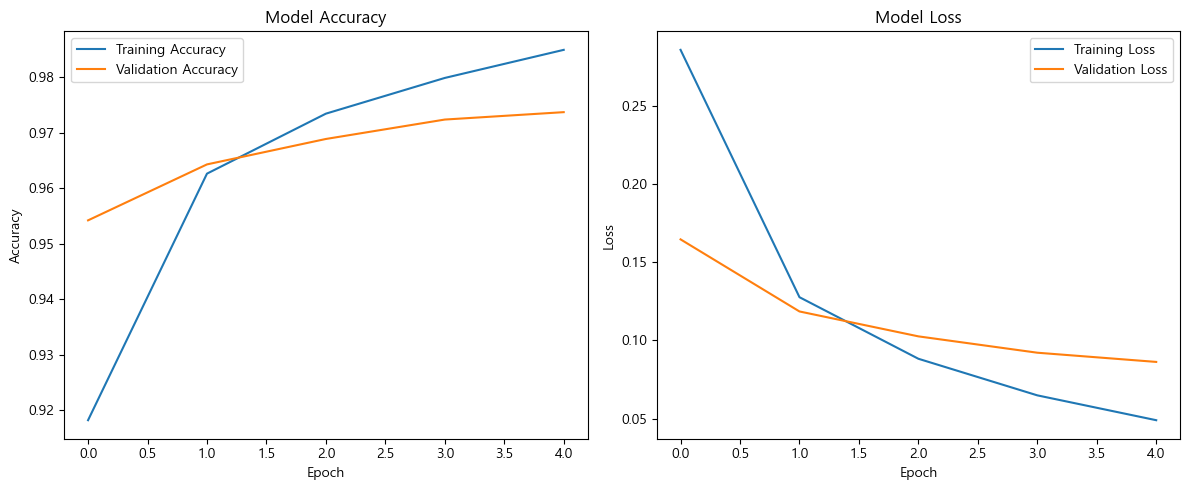

In [13]:
import matplotlib.pyplot as plt

# ----------------- Accuracy Graph -----------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.tight_layout()
plt.show()